#**Laboratorio di Introduzione alla Matematica Computazionale - Esercizi in Julia**

##**Esercitazione 5: Polinomi**

---
#1. Polinomi in Julia

In Julia, lavoriamo con i polinomi usando il pacchetto `Polynomials.jl`. Specificamente, Julia utilizza un tipo di dato specifico `Polynomial` dove i coefficienti sono ordinati dal grado più basso al più alto (ordine naturale).

Carichiamo le librerie necessarie.

In [3]:
import Pkg; Pkg.add("Polynomials")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Polynomials ─ v4.1.1
    Updating `~/.julia/environments/v1.12/Project.toml`
  [f27b6e38] + Polynomials v4.1.1
    Updating `~/.julia/environments/v1.12/Manifest.toml`
  [f27b6e38] + Polynomials v4.1.1
Precompiling packages...
  46897.7 ms  ✓ Polynomials
   3282.6 ms  ✓ Polynomials → PolynomialsRecipesBaseExt
   3328.3 ms  ✓ Polynomials → PolynomialsChainRulesCoreExt
  12494.6 ms  ✓ Polynomials → PolynomialsMakieExt
  4 dependencies successfully precompiled in 66 seconds. 480 already precompiled.


In [4]:
using Polynomials
using LinearAlgebra
using Plots

Per esempio, il polinomio
$$
p(x)=x^5+2x^4-5x^3+x-6
$$
si può rappresentare come

```julia
p = Polynomial([-6, 1, 0, -5, 2, 1])
```

Alcuni comandi utili per lavorare con i polinomi sono i seguenti (potete cercare uso e sintassi con la funzionalità `?`):
* Valutazione: `p(x)`
* Radici: `roots(p)`
* Prodotto: `p * q`
* Divisione: `divrem(p, q)`
* Derivata: `derivative(p)`


In [ ]:
q= Polynomial([-1, -1, 1])
r=roots(q)
println(r)

[-0.6180339887498948, 1.618033988749895]


Per fare pratica, provate a definire in Julia il polinomio $p(x)=x^2-x-1$, calcolate le sue radici e verificate che il polinomio si annulla numericamente in corrispondenza delle radici calcolate:

```julia
# Esempio: p(x) = x^2 - x - 1
# In Julia i coefficienti partono da x^0: [-1, -1, 1]
p = Polynomial([-1, -1, 1])
r = roots(p)
println("Radici: ", r)
println("Verifica p(r): ", p.(r))
```

In [ ]:
q= Polynomial([-1, -1, 1])
r=roots(q)
println(r)
println(q.(r))

[-0.6180339887498948, 1.618033988749895]
[-5.817207032317949e-17, 1.21465788570442e-16]


Viceversa, scegliamo un vettore `r` contenente le radici e calcoliamo i coefficienti del polinomio monico `p` corrispondente, quindi verifichiamo che `p` si annulli sulle radici assegnate e che il calcolo numerico delle radici di `p` restituisca gli stessi valori assegnati all'inizio:

```julia
# Definire le radici
radici = [1, 2, 3]

# Calcolare il polinomio: (x-1)(x-2)(x-3) = -6 + 11x - 6x² + x³
p = fromroots(radici)

#  Mostrare il polinomio
println(p)
# Output: Polynomial(-6 + 11*x - 6*x^2 + x^3)

# Valutare il polinomio nelle radici
println(p.(radici))

# Calcolare le radici del polinomio
radicivar = roots(p)
```


In [ ]:
rad=[1, 2, 3]
g=fromroots(rad)
println(g)
println(g.(rad))

-6 + 11*x - 6*x^2 + x^3
[0, 0, 0]


La funzione `fromroots` permette anche di calcolare il polinomio caratteristico di una matrice. Per esempio, definiamo $p(x)$ come il polinomio caratteristico della matrice
$$
A=\left[\begin{array}{cc}
0&1\\1&1 \end{array}\right].
$$
Il teorema di Cayley-Hamilton implica che $p(A)=0$. Verifichiamolo numericamente:
```julia
A=[0 1; 1 1]
p = fromroots(eigvals(A))
println(p)
println(p(A))
```
Dall'ultimo comando, dovreste ottenere una matrice numericamente nulla.

In [ ]:
A=[0 1; 1 1]
auto=fromroots(eigvals(A))
println(auto)
println(auto(A))

-1.0 - 1.0*x + 1.0*x^2
[1.1102230246251565e-16 0.0; 0.0 1.1102230246251565e-16]


Usando `*` e `divrem` possiamo moltiplicare e dividere polinomi. Per esempio, definiamo $p(x)=x^3-6x^2+12x-8$, dividiamo $p(x)$ per $q(x)=x-2$, poi moltiplichiamo il risultato di nuovo per $q(x)$ e aggiungiamo il resto, e verifichiamo di aver ottenuto proprio $p(x)$:
```julia
p=Polynomial([-8, 12, -6, 1])
q=Polynomial([-2, 1])
(g, r) = divrem(p,q)
println(g*q+r)
```

Per tracciare il grafico di una funzione polinomiale definita su un intervallo $[a,b]$ possiamo valutare il polinomio su una discretizzazione dell'intervallo e applicare il comando `plot` ai risultati ottenuti. Per esempio, supponiamo di voler tracciare il grafico di $p(x)=x^4-9x^3+21x^2+x-30$ definito sull'intervallo $[-2,6]$:
```julia
p_coeffs = [-30, 1, 21, -9, 1]
p = Polynomial(p_coeffs)
# Generare 500 punti equispaziati fra -2 e 6
t = range(-2, 6, length=500)
# Valutare il polinomio in ogni punto in t
pv = p.(t)
# Grafico
plot(t, pv, label="p(x)", title="Grafico del Polinomio", lw=2)
```

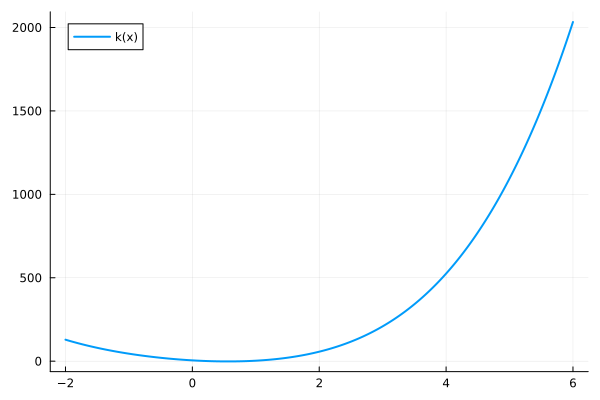

In [ ]:
k_coeffs=[5, -22, 18, 1, 1]
k=Polynomial(k_coeffs)
t=range(-2, 6, length=500)
kv=k.(t)
plot(t, kv, label="k(x)", lw=2)

**Esercizio 1**. Scrivere una funzione `perturbed_poly(p,t)` che prenda in ingresso un vettore `p` contenente i coefficienti di un polinomio e un numero reale `t`, e disegni sul piano complesso (in una stessa finestra grafica) gli zeri di `p` e gli zeri del polinomio ottenuto sommando `t` al coefficiente costante di `p`.

Si applichi poi la funzione appena definita agli esempi seguenti:

* $p(x)=x^4-1$, $t=0.02$
* $q(x)=(x-1)^4$, $t=0.02$

Si traccino (in una terza figura) i grafici dei due polinomi in un intorno di $1$,  per esempio nell'intervallo $[0,1.5]$.

Che cosa si puo` constatare confrontando le radici dei polinomi di partenza e dei polinomi perturbati? In particolare, che differenze notate tra il comportamento del primo e del secondo esempio? Cosa mostrano i grafici dei polinomi disegnati vicino a 1?

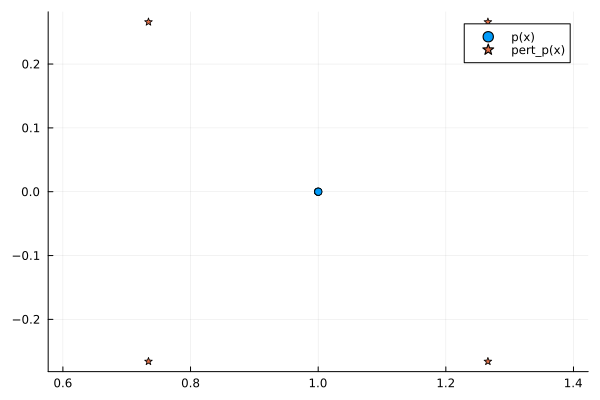

In [10]:
function perturbed_poly(h,n)
q=Polynomial(h)
h[1]=h[1]+n
L=Polynomial(h)
rot=roots(q)
rotp=roots(L)

scatter(real.(rot), imag.(rot), label="p(x)", aspect_ratio=:equal)
scatter!(real.(rotp), imag.(rotp), markershape=:star, label="pert_p(x)")

end
m=0.02
w=[-1.0, 0, 0, -0, 1]
#scatter(real([0]), imag([0]), aspect_ratio=:equal)
perturbed_poly(w, m)
z=[1.0, -4, 6, -4, 1]
perturbed_poly(z, m)


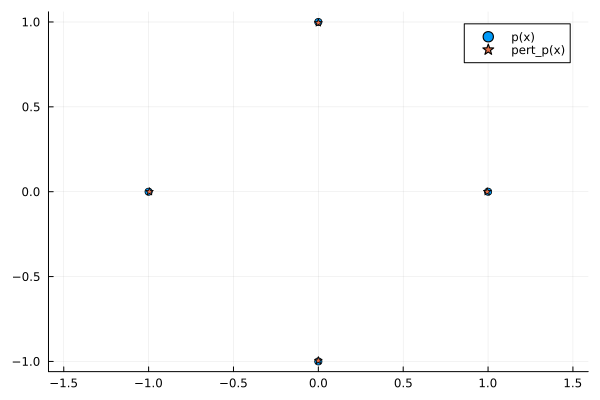

In [11]:
m=0.02
w=[-1.0, 0, 0, -0, 1]
#scatter(real([0]), imag([0]), aspect_ratio=:equal)
perturbed_poly(w, m)

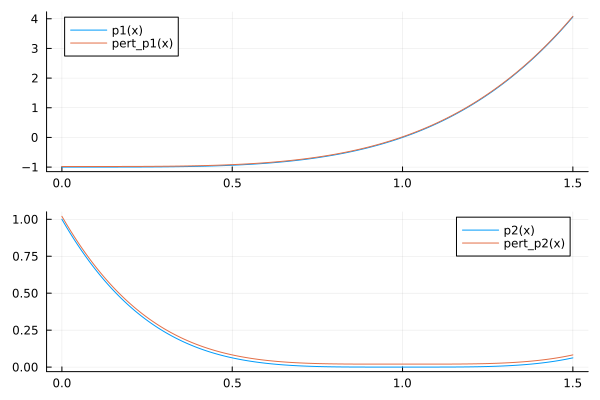

In [26]:
t=range(0, 1.5, length=500)

function perturbed_pol(h, j, n)

q1=Polynomial(h)
h[1]=h[1]+n
L1=Polynomial(h)
q1v=q1.(t)
L1v=L1.(t)

q2=Polynomial(j)
j[1]=j[1]+n
L2=Polynomial(j)
q2v=q2.(t)
L2v=L2.(t)


p1 = plot(t, [q1v L1v], label=["p1(x)" "pert_p1(x)"])
#p2 = plot(t, L1v, label="pert_p1(x)")

p3 = plot(t, [q2v L2v], label=["p2(x)" "pert_p2(x)"])
#p4 = plot(t, L2v, label="pert_p2(x)")

plot(p1, p3, layout=(2, 1))
#plot!(p2, p4, layout=(2, 1))

end
m=0.02
w=[-1.0, 0, 0, -0, 1]
z=[1.0, -4, 6, -4, 1]
#scatter(real([0]), imag([0]), aspect_ratio=:equal)
perturbed_pol(w, z, m)

L'Esercizio 1 mostra sperimentalmente come le radici multiple di un polinomio siano in generale mal condizionate: se $p(x)$ ha una radice con molteplicità $k$ e applico ai coefficienti di $p(x)$ una perturbazione dell'ordine di $\epsilon$, la radice multipla si ``spezza'' in $k$ radici distinte a distanza circa $\epsilon^{\frac1k}$.

---
#2. Polinomi di Legendre e Chebyshev

**Esercizio 2**.

1. *Polinomi di Legendre*.
I polinomi di Legendre sono definiti in modo ricorsivo come

\begin{eqnarray*}
&& p_0(x)=1,\\
&& p_1(x)=x,\\
&& p_n(x)=\frac{(2n-1)xp_{n-1}(x)-(n-1)p_{n-2}(x)}{n},\qquad n\geq 2.
\end{eqnarray*}

Scrivere una funzione `legendre(K)` che prenda in ingresso un intero positivo `K` e disegni il grafico dei primi `K` polinomi di Legendre sull'intervallo $[-1,1]$.

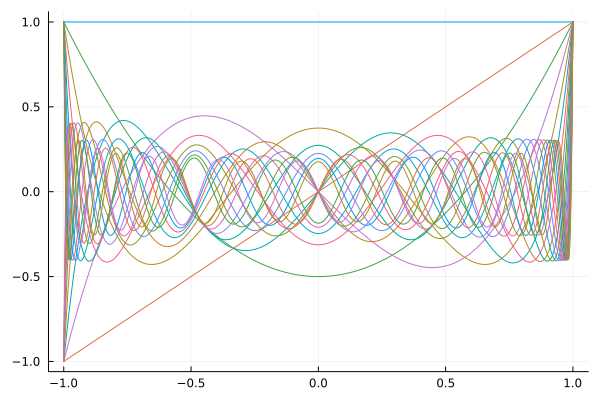

In [61]:
function legendre(k)

s= range(-1, 1, length=500)
xp= Polynomial([0, 1])

if k>=0

f1=Polynomial([1])
p = plot(s, f1.(s), legend=false)

end

if k>0
f2=Polynomial([0, 1])
plot!(p, s, f2.(s))
end

f3=Polynomial()

for i in 2:k


f3=((2*i-1)*xp*f2-(i-1)*f1)/i
f1=f2
f2=f3

    plot!(p, s, f3.(s))

end


display(p)


end

legendre(20)

2. *Polinomi di Chebyshev*.
I polinomi di Chebyshev di prima specie sono definiti in modo ricorsivo come

\begin{eqnarray*}
&& p_0(x)=1,\\
&& p_1(x)=x,\\
&& p_n(x)=2xp_{n-1}(x)-p_{n-2}(x),\qquad n\geq 2.
\end{eqnarray*}

Scrivere una funzione `cheby(K)` che prenda in ingresso un intero positivo `K` e disegni il grafico dei primi `K` polinomi di Chebyshev sull'intervallo $[-1,1]$.

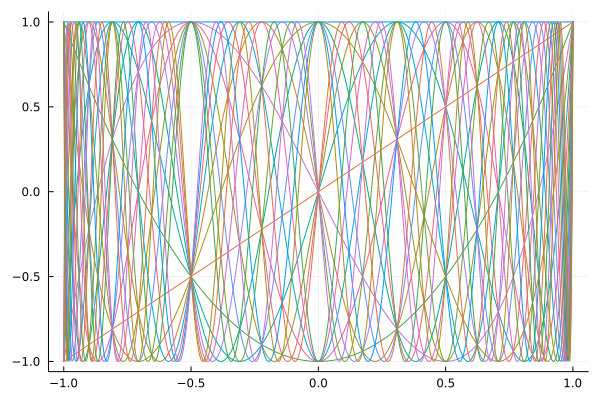

In [64]:
function cheby(k)

s= range(-1, 1, length=500)
xp= Polynomial([0, 1])

if k>=0

f1=Polynomial([1])
p = plot(s, f1.(s), legend=false)

end

if k>0
f2=Polynomial([0, 1])
plot!(p, s, f2.(s))
end

f3=Polynomial()

for i in 2:k


f3=2*xp*f2-f1
f1=f2
f2=f3

    plot!(p, s, f3.(s))

end


display(p)


end

cheby(20)

Osservando i grafici dei polinomi di Legendre e Chebyshev, cosa potete dire delle loro radici?

---
#3. Esponenziale di una matrice e polinomi di Taylor

Data una matrice A di dimensioni $n\times n$, l'esponenziale di $A$ è la matrice
$$
e^A=\sum_{k=0}^{\infty}\frac{A^k}{k!}=I+A+\frac12 A^2+\frac16 A^3+\ldots.
$$
In Julia l'esponenziale di `A` si calcola con la funzione `exp(A)` (da non confondersi con `exp.(A)`, che calcola una matrice i cui elementi sono gli esponenziali degli elementi corrispondenti della matrice `A`)

Vogliamo capire se l'approssimazione di $e^A$ data dai polinomi di Taylor, cioè dalle serie troncate $p_m(A)=I+A+\frac12 A^2+\ldots+\frac{1}{m!}A^m$ converge rapidamente ed è numericamente valida. In altre parole, vogliamo studiare numericamente la successione $\{s_m\}_{m\in\mathbb{N}}$, dove
$$
s_m=\|e^A-p_m(A)\|_2.
$$
E' utile sapere che in Julia la norma 2 di una matrice si calcola con la funzione `norm` e il fattoriale di un numero intero `i` con la funzione `factorial(big(i))` (invece che semplicemente `factorial(i)`, per evitare problemi di rappresentazione dei numeri attraverso il computer).


**Esercizio 3**. Scrivere una funzione `err=convergenza_exp(A,k)` che prenda in ingresso una matrice quadrata `A` e un intero positivo `k`, e restituisca il vettore `err` dei primi `k` elementi della successione $\{s_m\}_{m\in\mathbb{N}}$.

Si testi poi la funzione appena definita, disegnando in modo opportuno l'andamento degli errori di approssimazione di $e^A$ nei casi seguenti:

\begin{eqnarray*}
&&A=\left[\begin{array}{ccc}
0&0&0\\ 0&0.2&0\\ 0&0&0.5
\end{array}\right],\\
&&A=\left[\begin{array}{ccc}
1.5&0&0\\ 0&2&0\\ 0&0&5
\end{array}\right],\\
&&A=\left[\begin{array}{cc}
40 & 32 \\ 16& 18
\end{array}\right],\\
&&A=\left[\begin{array}{cc}
-49&24\\-64& 31
\end{array}\right].
\end{eqnarray*}

Che cosa osservate? Quali grandezze associate alla matrice secondo voi influenzano la velocità di convergenza?  